# Color Histogram Correlation

In [2]:
# Import libraries for correlation
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load dataset path
dataset_dir = "crab-images-dataset/test"

In [4]:
# Extract and compute histogograms for red, green, and blue (RGB) channels
def extract_color_histogram(image_path, bins=(8, 8, 8)):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Compute histograms for Red, Green, Blue channels
    hist_b = cv2.calcHist([image], [0], None, [bins[0]], [0, 256]).flatten()
    hist_g = cv2.calcHist([image], [1], None, [bins[1]], [0, 256]).flatten()
    hist_r = cv2.calcHist([image], [2], None, [bins[2]], [0, 256]).flatten()
    
    # Normalize histograms
    hist_r /= (hist_r.sum() + 1e-6)
    hist_g /= (hist_g.sum() + 1e-6)
    hist_b /= (hist_b.sum() + 1e-6)
    
    return np.concatenate([hist_r, hist_g, hist_b])

In [5]:
# Dataset Preparation: Store species and histogram features in the data[] for dataframe
data = []

for species in os.listdir(dataset_dir):  
    species_path = os.path.join(dataset_dir, species)
    if os.path.isdir(species_path):  # Ensure it's a directory
        for image_file in os.listdir(species_path):
            if image_file.endswith(('.jpg', '.png')):  # Only process images
                image_path = os.path.join(species_path, image_file)
                hist = extract_color_histogram(image_path)
                
                # Store species label and histogram features
                data.append([species] + hist.tolist())

In [6]:
# Convert to dataframe
columns = ["Species"] + [f"Bin_{i}" for i in range(len(hist))]
df = pd.DataFrame(data, columns=columns)

In [7]:
# Display rows
print(df.head())

          Species     Bin_0     Bin_1     Bin_2     Bin_3     Bin_4     Bin_5  \
0  dungeness_crab  0.271881  0.140366  0.186813  0.197296  0.140228  0.022293   
1  dungeness_crab  0.270309  0.291656  0.161377  0.119904  0.085327  0.044708   
2  dungeness_crab  0.318146  0.274994  0.161819  0.096115  0.074234  0.046143   
3  dungeness_crab  0.137604  0.195541  0.230026  0.143845  0.109589  0.069199   
4  dungeness_crab  0.229675  0.186264  0.122299  0.111481  0.088043  0.194534   

      Bin_6     Bin_7     Bin_8  ...    Bin_14    Bin_15    Bin_16    Bin_17  \
0  0.019684  0.021439  0.079697  ...  0.091248  0.042007  0.007767  0.043884   
1  0.019592  0.007126  0.208939  ...  0.032501  0.017792  0.154831  0.253967   
2  0.023270  0.005280  0.251404  ...  0.013397  0.002151  0.160980  0.151688   
3  0.080826  0.033371  0.042236  ...  0.141083  0.086639  0.018219  0.037796   
4  0.067245  0.000458  0.065582  ...  0.333191  0.033279  0.013702  0.036270   

     Bin_18    Bin_19    Bin_20 

In [8]:
# Compute mean color histogram for each species
df_avg = df.groupby("Species").mean()

In [9]:
# Display average histograms per species
print(df_avg)

                   Bin_0     Bin_1     Bin_2     Bin_3     Bin_4     Bin_5  \
Species                                                                      
dungeness_crab  0.214165  0.196799  0.160632  0.139597  0.119502  0.083689   
fiddler_crab    0.139179  0.158943  0.187214  0.198132  0.152588  0.090695   
hermit_crab     0.156510  0.157059  0.152240  0.154967  0.150624  0.116274   
king_crab       0.242624  0.205257  0.165956  0.128153  0.099884  0.071862   
rock_crab       0.176584  0.181778  0.180169  0.168653  0.128888  0.082889   

                   Bin_6     Bin_7     Bin_8     Bin_9  ...    Bin_14  \
Species                                                 ...             
dungeness_crab  0.046564  0.039052  0.124997  0.161540  ...  0.070022   
fiddler_crab    0.047785  0.025463  0.092091  0.122372  ...  0.070765   
hermit_crab     0.072514  0.039812  0.095584  0.128551  ...  0.094569   
king_crab       0.047157  0.039107  0.152783  0.170094  ...  0.064379   
rock_crab      

In [20]:
# Select two species for color histogram comparison
def cmpr_color_hist_species(target, cmpr_species):
    hist1 = df[df["Species"] == target].iloc[:, 1:].mean()
    hist2 = df[df["Species"] == cmpr_species].iloc[:, 1:].mean()
    
    # Plot histograms using line graph
    plt.figure(figsize=(15, 5))
    plt.plot(hist1, color='red', label=target)
    plt.plot(hist2, color='blue', label=cmpr_species)
    plt.title(f"Color Histogram Comparison: {target} vs {cmpr_species}")
    plt.legend()

    # Save the figure
    filename = f"plot_{target}_vs_{cmpr_species}.png"
    plt.savefig(filename)
    
    plt.show()

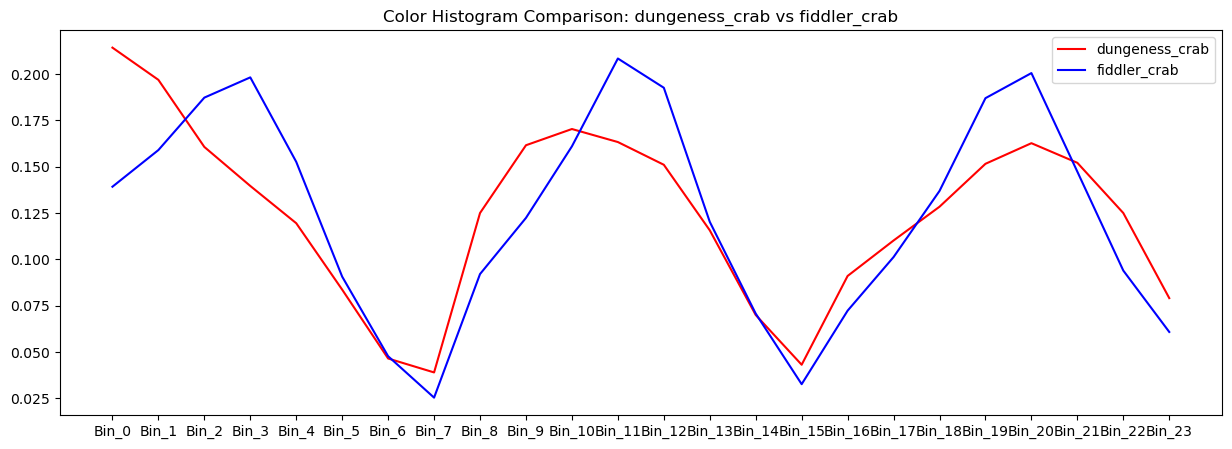

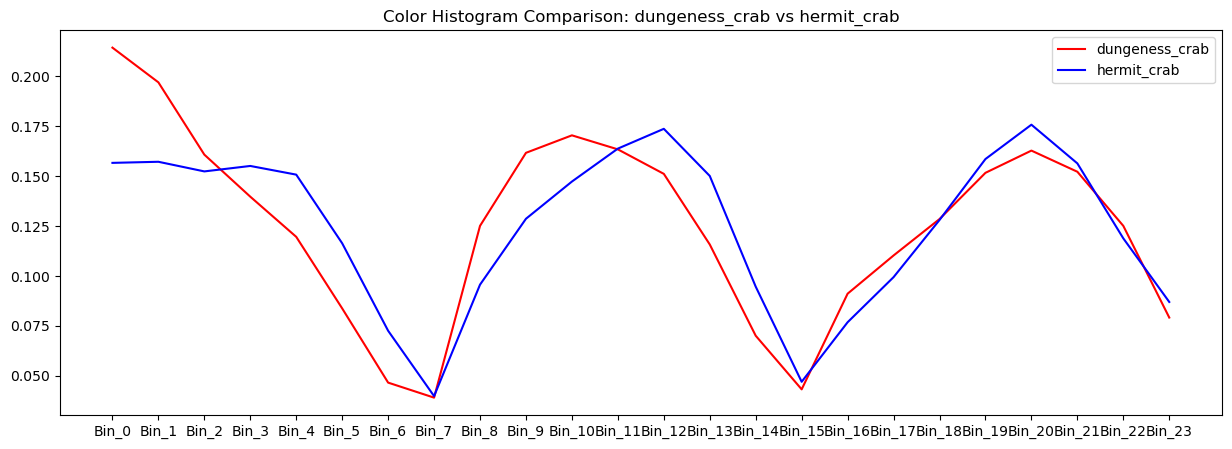

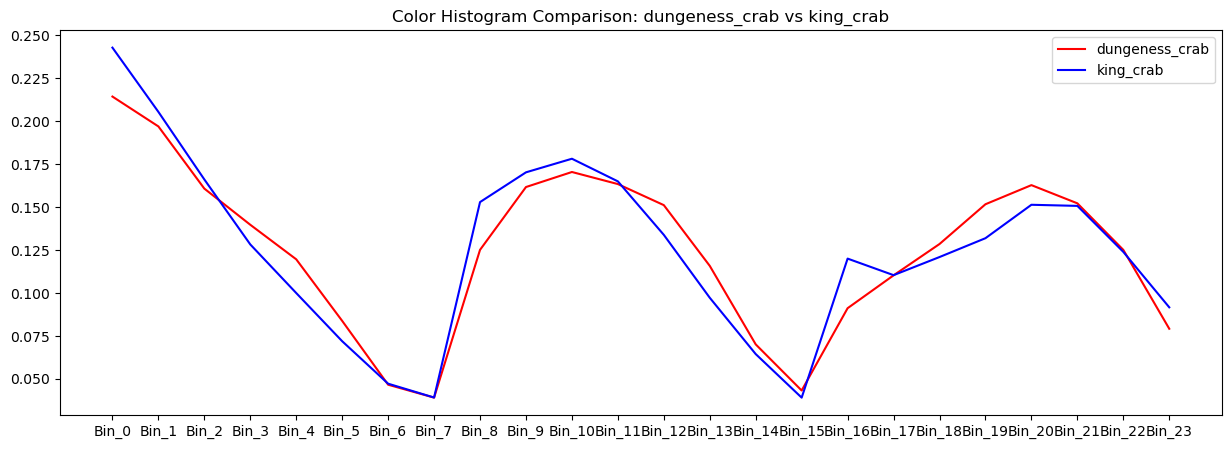

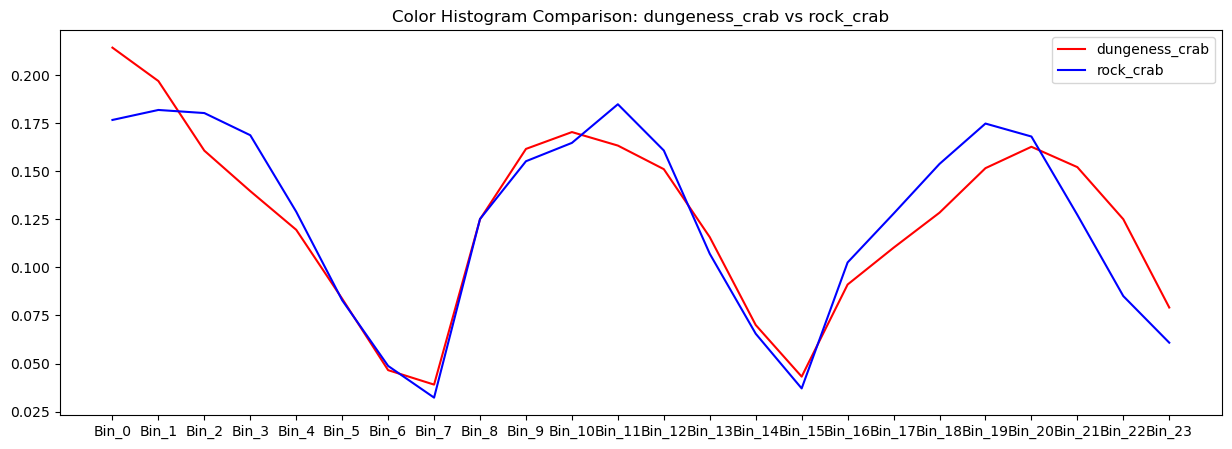

In [13]:
# Compare Dungeness Crab to other species
target = "dungeness_crab"
species_list = ["fiddler_crab", "hermit_crab", "king_crab", "rock_crab"]

for species in species_list:
    cmpr_color_hist_species(target, species)

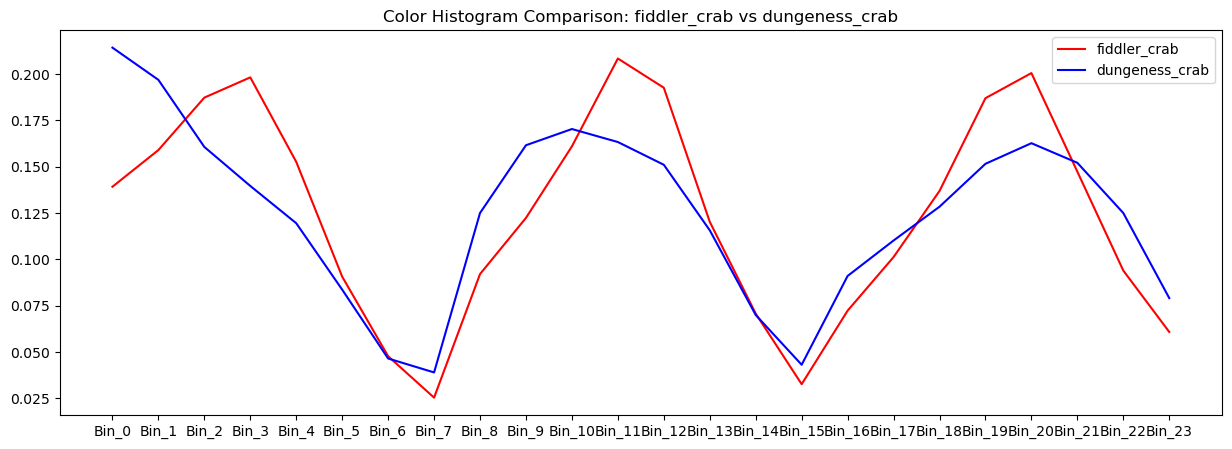

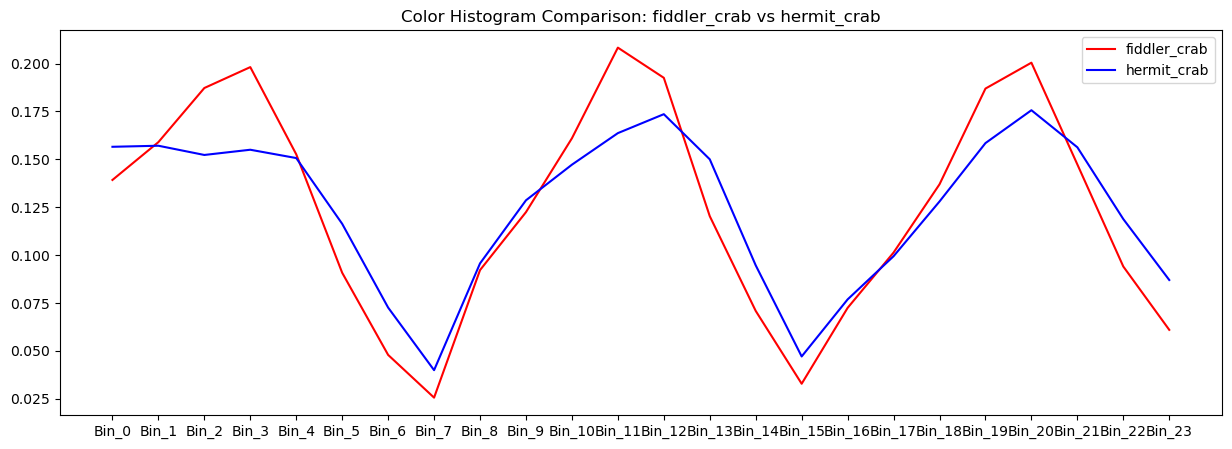

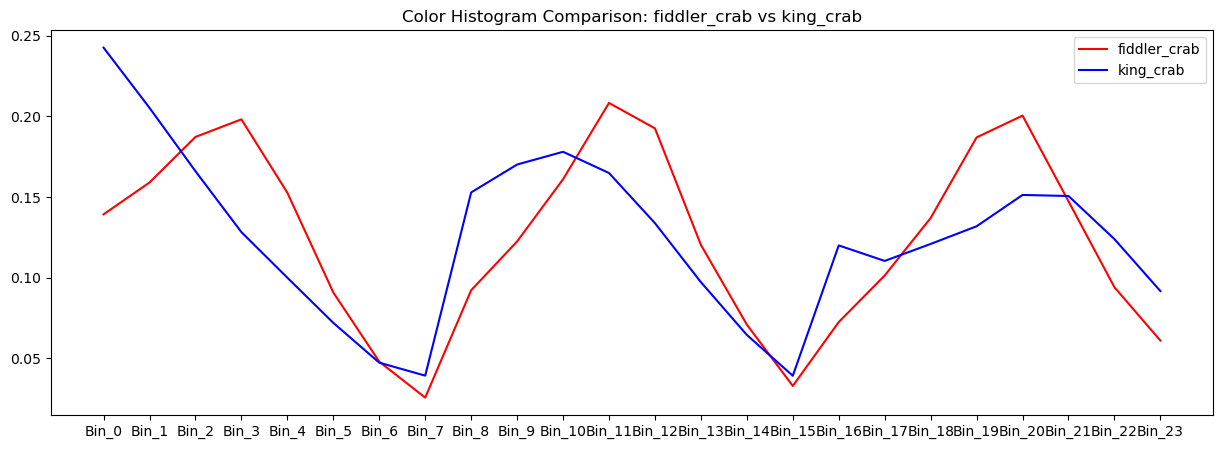

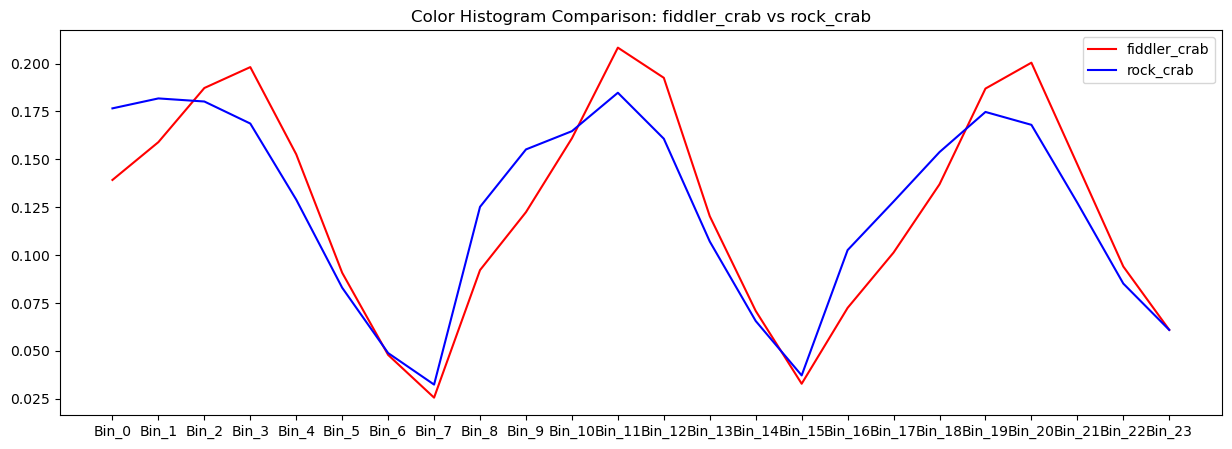

In [14]:
# Compare Fiddler Crab to other species
target =  "fiddler_crab"
species_list = ["dungeness_crab", "hermit_crab", "king_crab", "rock_crab"]

for species in species_list:
    cmpr_color_hist_species(target, species)

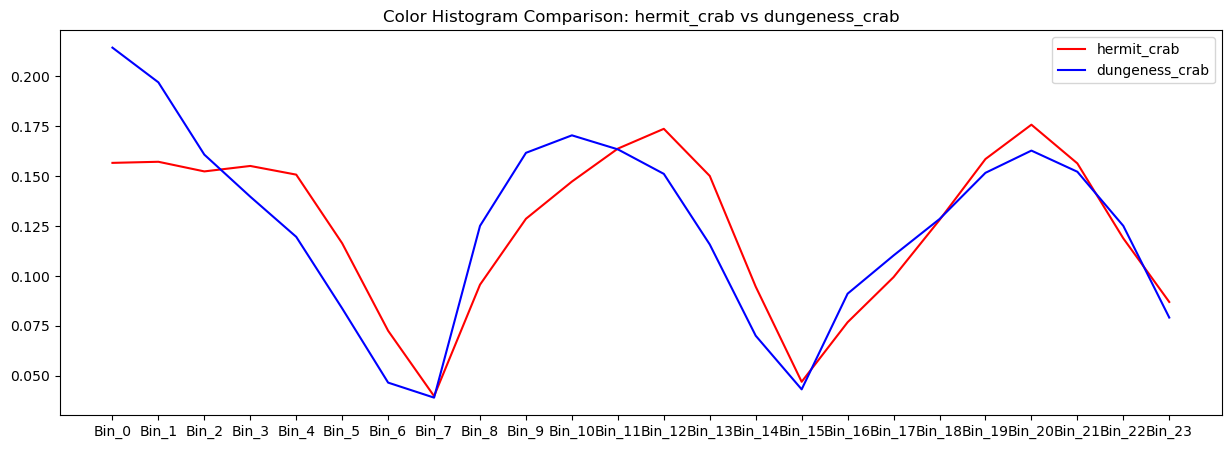

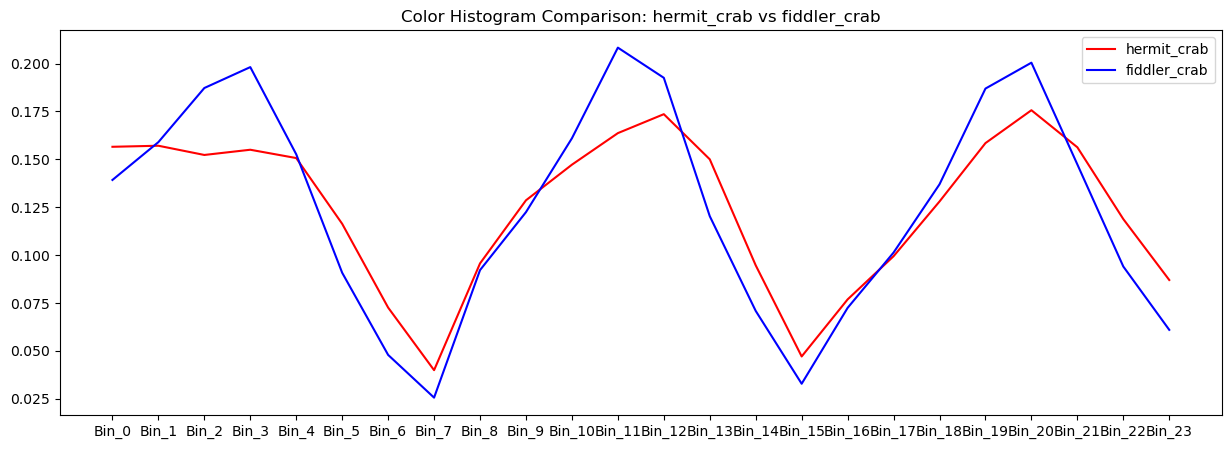

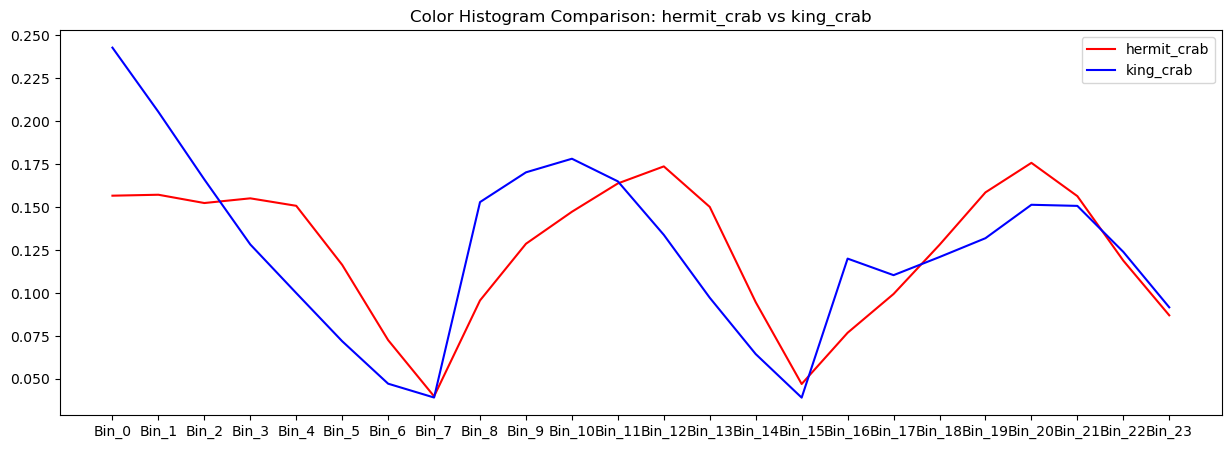

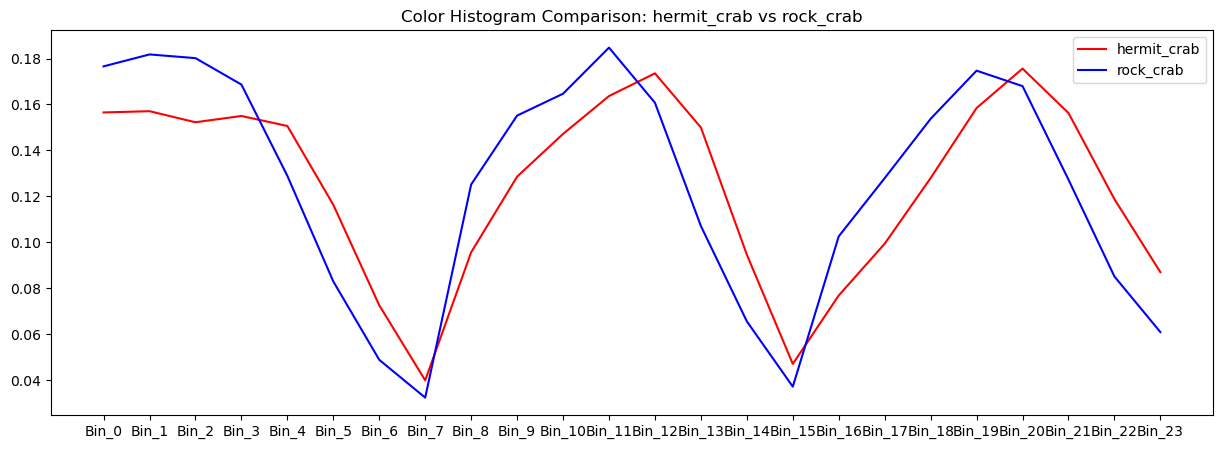

In [15]:
# Compare Hermit Crab to other species
target =  "hermit_crab"
species_list = ["dungeness_crab", "fiddler_crab", "king_crab", "rock_crab"]

for species in species_list:
    cmpr_color_hist_species(target, species)

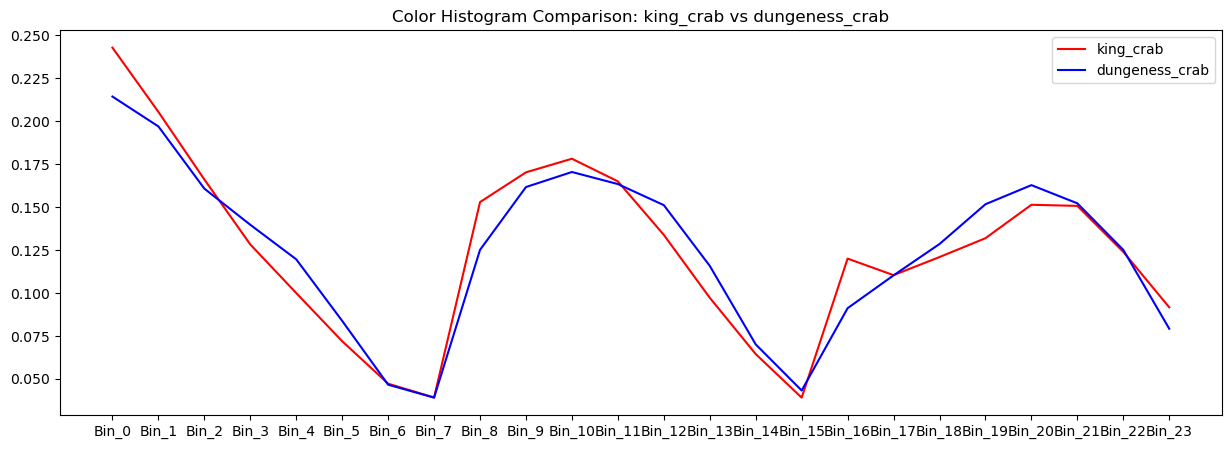

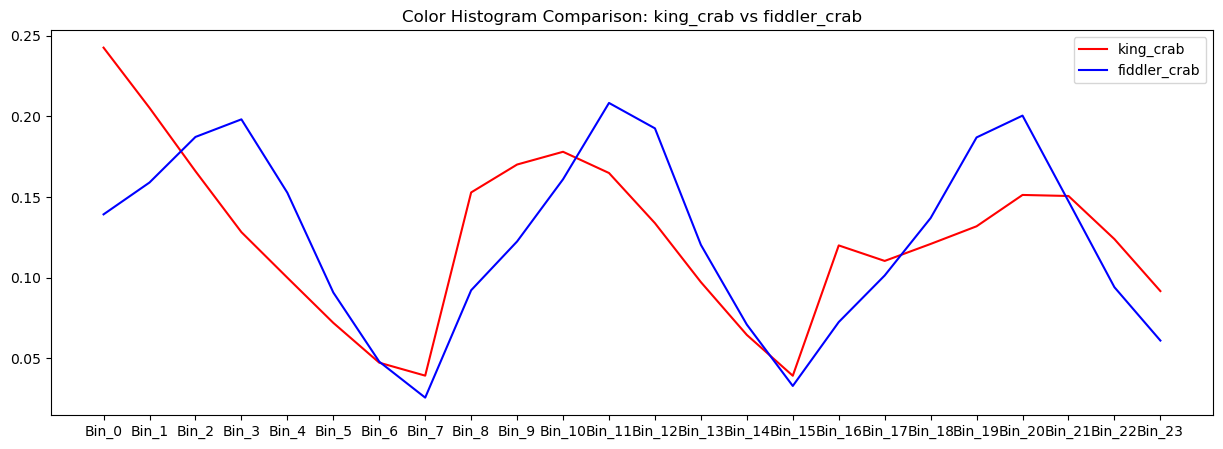

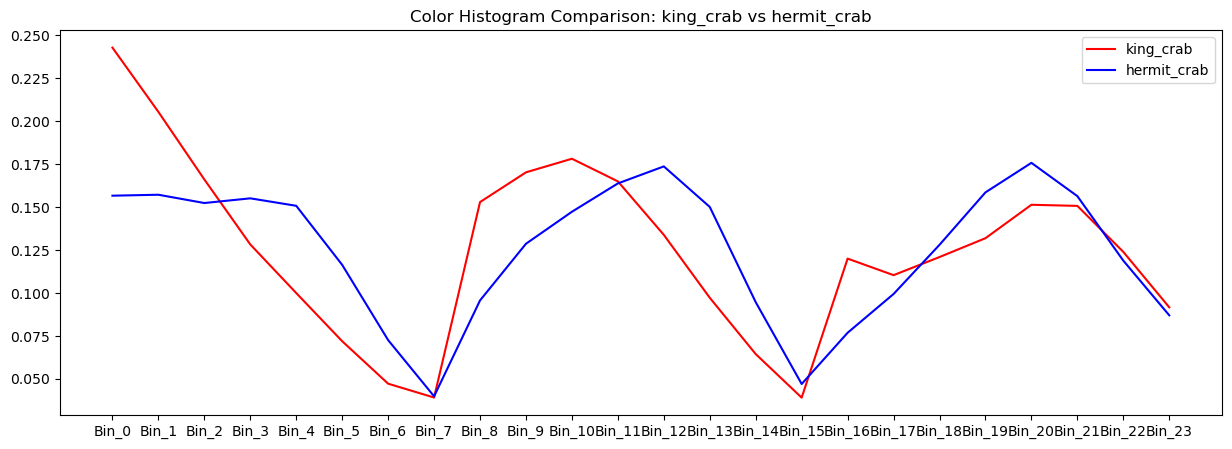

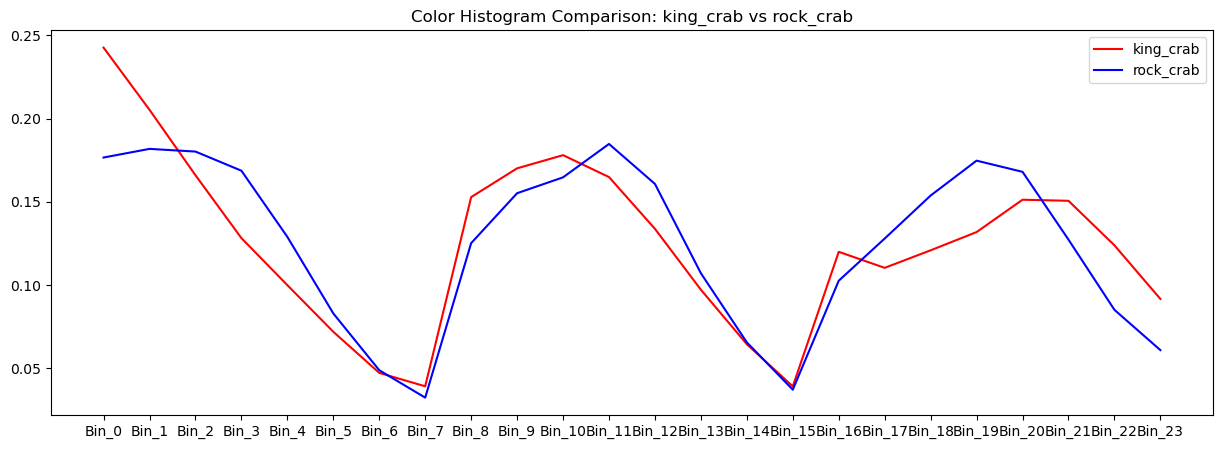

In [16]:
# Compare King Crab to other species
target =  "king_crab"
species_list = ["dungeness_crab", "fiddler_crab", "hermit_crab", "rock_crab"]

for species in species_list:
    cmpr_color_hist_species(target, species)

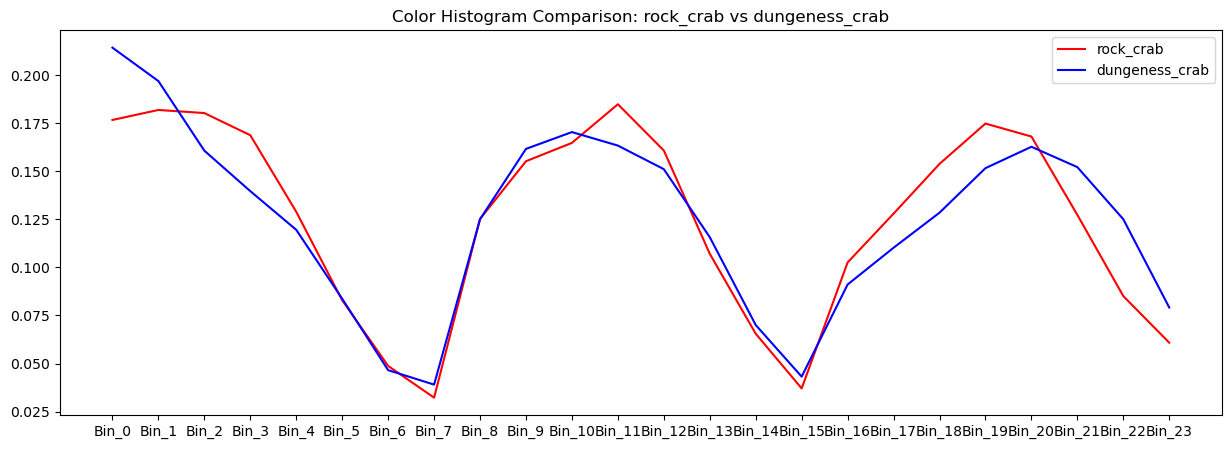

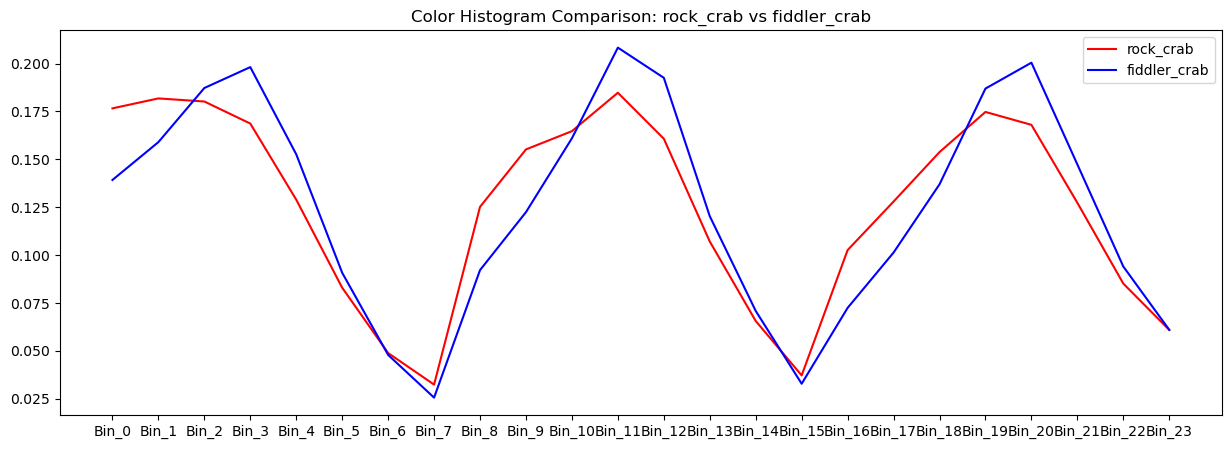

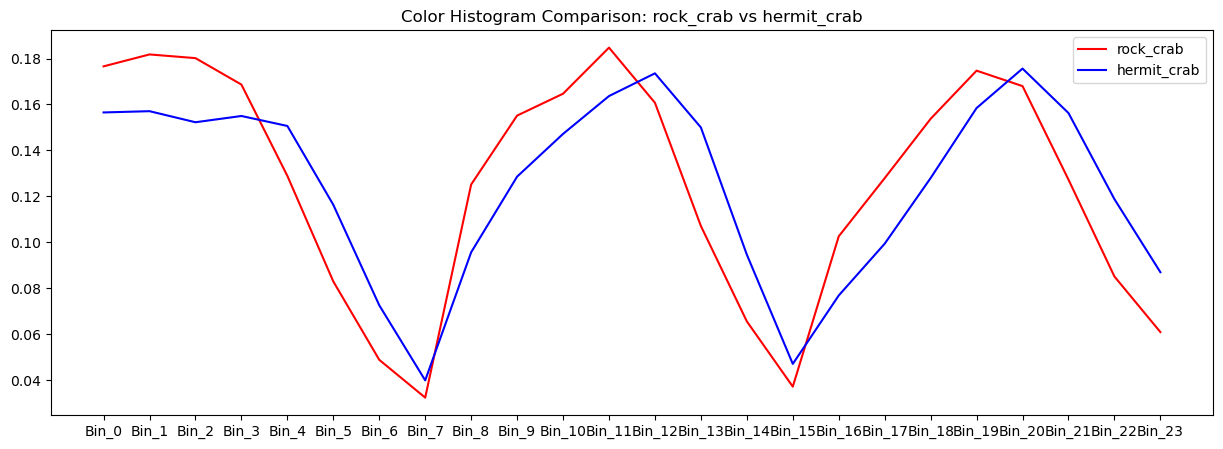

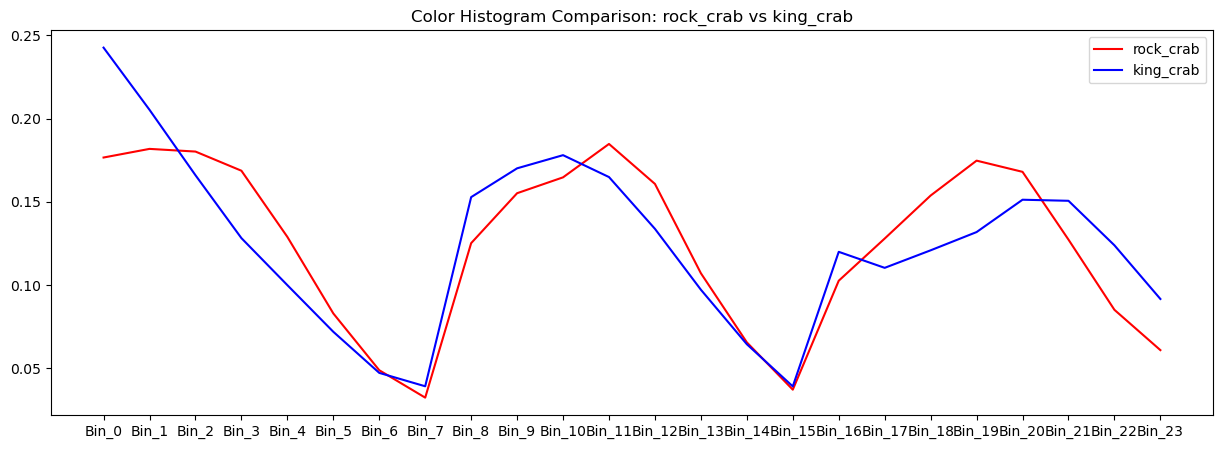

In [17]:
# Compare Rock Crab to other species
target =  "rock_crab"
species_list = ["dungeness_crab", "fiddler_crab", "hermit_crab", "king_crab"]

for species in species_list:
    cmpr_color_hist_species(target, species)

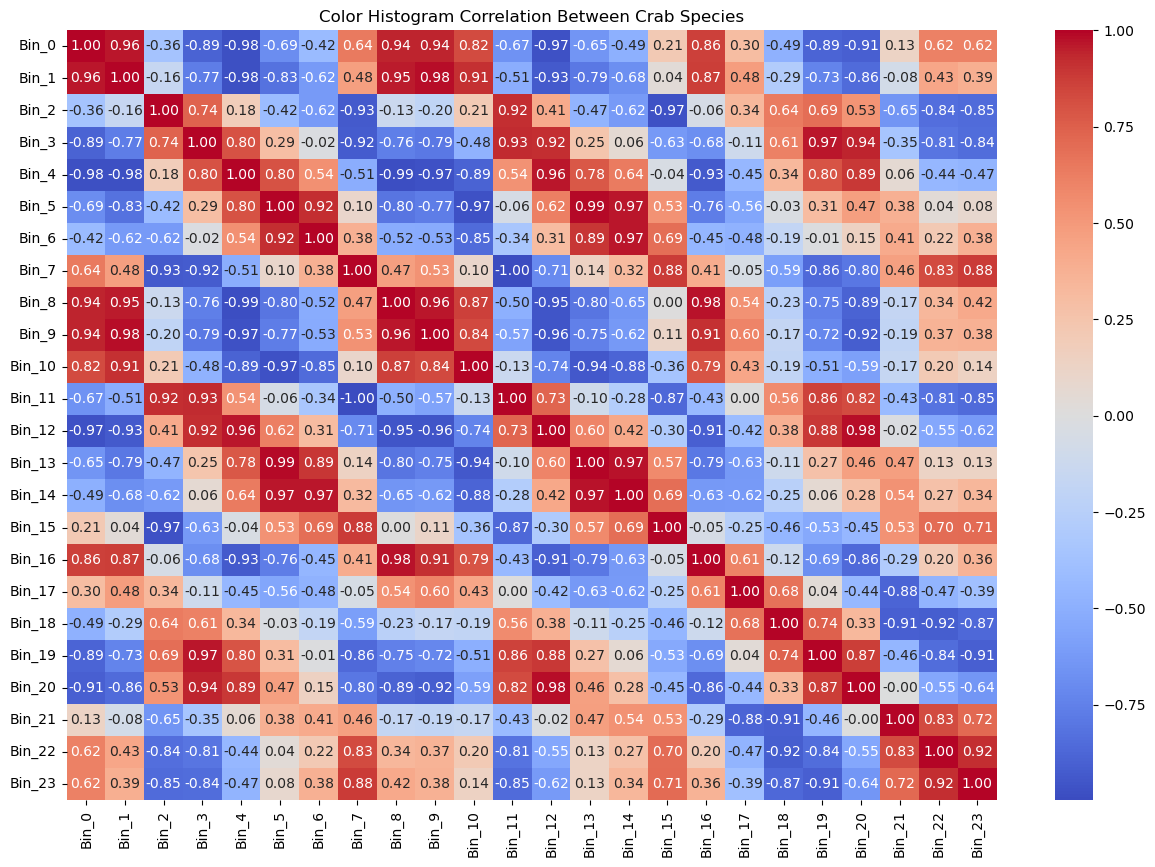

In [18]:
# Display correlation matrix between crab species
corr_matrix = df_avg.corr()

# Plot heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Color Histogram Correlation Between Crab Species")

# Save the figure
plt.savefig("plot_color_hist_heatmap.png")
plt.show()

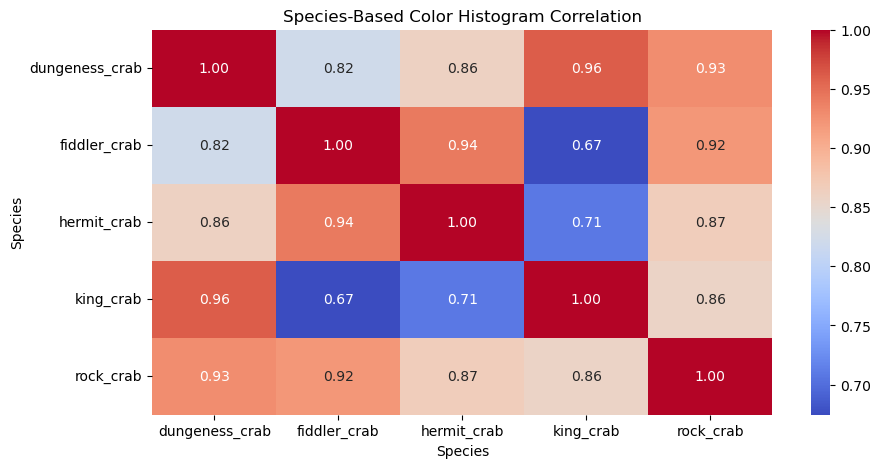

In [19]:
# Display species-based correlation matrix
corr_matrix = df_avg.T.corr()

# Plot heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Species-Based Color Histogram Correlation")

# Save the figure
plt.savefig("plot_color_hist_heatmap_species-based.png")
plt.show()